# 02 - Biến mục tiêu, nhân khẩu học và thông tin nhập viện

**Mục tiêu:** phân tích biến mục tiêu `readmitted` và các yếu tố cơ bản liên quan đến bệnh nhân/lần nhập viện: tuổi, giới tính, chủng tộc, thời gian nằm viện, loại nhập viện, nguồn nhập viện và tình trạng xuất viện.

Các cột tập trung:
- `readmitted`
- `race`, `gender`, `age`
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id`
- `time_in_hospital`

## 1. Load dữ liệu đã xử lý sơ bộ

Ở file này, dữ liệu được đọc lại từ `diabetic_data.csv` và xử lý nhẹ:
- Chuyển `?` thành missing value (`NaN`).
- Loại các dòng có `gender = Unknown/Invalid` vì số lượng thường rất ít và khó phân tích theo giới tính.
- Tạo thêm nhãn nhị phân `readmitted_binary` cho bài toán có/không tái nhập viện.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập hiển thị bảng và style biểu đồ.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

# Notebook nằm trong thư mục Exploratory Data Analysis, file CSV nằm ở thư mục gốc project.
data_candidates = [
    Path("diabetic_data.csv"),
    Path("..") / "diabetic_data.csv",
]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Không tìm thấy diabetic_data.csv. Hãy kiểm tra lại vị trí file dữ liệu.")

# na_values='?' giúp pandas hiểu dấu ? là giá trị thiếu.
df = pd.read_csv(data_path, na_values="?")

# Clean nhẹ: bỏ giới tính Unknown/Invalid vì không đại diện cho nhóm giới tính rõ ràng.
df = df[df["gender"] != "Unknown/Invalid"].copy()

# Tạo nhãn nhị phân: NO = 0, <30 hoặc >30 = 1.
df["readmitted_binary"] = np.where(df["readmitted"].eq("NO"), 0, 1)

print(f"Đã đọc dữ liệu từ: {data_path.resolve()}")
print(f"Kích thước sau clean nhẹ: {df.shape[0]:,} dòng x {df.shape[1]:,} cột")
df.head()

Đã đọc dữ liệu từ: D:\HocTap\KT&XLTT\CUOIKI\diabetic_data.csv
Kích thước sau clean nhẹ: 101,763 dòng x 51 cột


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33304\3301237966.py:26: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,1
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


### Mapping mã nhập viện

Các cột `admission_type_id`, `admission_source_id`, `discharge_disposition_id` là mã số. Tạo thêm cột diễn giải để bảng và biểu đồ dễ đọc hơn.

In [2]:
# Mapping tham khảo cho các mã nhập viện/xuất viện thường gặp trong bộ dữ liệu Diabetes 130-US hospitals.
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped",
}

admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from hospital",
    5: "Transfer from SNF",
    6: "Transfer from health care facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from critical access hospital",
    11: "Normal Delivery",
    12: "Premature Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    15: "Not Available",
    17: "NULL",
    20: "Not Mapped",
    22: "Transfer from another facility",
    25: "Transfer from ambulatory surgery center",
    26: "Transfer from hospice",
}

discharge_disposition_map = {
    1: "Discharged to home",
    2: "Transferred to short term hospital",
    3: "Transferred to SNF",
    4: "Transferred to ICF",
    5: "Transferred to inpatient care",
    6: "Home with home health service",
    7: "Left AMA",
    8: "Home under care of home IV provider",
    9: "Admitted as inpatient",
    10: "Neonate discharged to another hospital",
    11: "Expired",
    12: "Still patient/expected return outpatient",
    13: "Hospice/home",
    14: "Hospice/medical facility",
    15: "Transferred within institution",
    16: "Transferred to another institution outpatient",
    17: "Transferred to another institution emergency",
    18: "NULL",
    19: "Expired at home",
    20: "Expired in medical facility",
    21: "Expired place unknown",
    22: "Transferred to rehab facility",
    23: "Transferred to long term care hospital",
    24: "Transferred to nursing facility",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Transferred to federal health care facility",
    28: "Transferred to psychiatric hospital",
    29: "Transferred to critical access hospital",
    30: "Transferred to another type of facility",
}

def map_id(series, mapping):
    # Giữ lại ID trong nhãn để tránh mất thông tin khi có mã chưa được mapping.
    return series.map(lambda x: f"{int(x)} - {mapping.get(int(x), 'ID chưa mapping')}" if pd.notna(x) else "Missing")

df["admission_type"] = map_id(df["admission_type_id"], admission_type_map)
df["admission_source"] = map_id(df["admission_source_id"], admission_source_map)
df["discharge_disposition"] = map_id(df["discharge_disposition_id"], discharge_disposition_map)

df[["admission_type_id", "admission_type", "admission_source_id", "admission_source", "discharge_disposition_id", "discharge_disposition"]].head()

,admission_type_id,admission_type,admission_source_id,admission_source,discharge_disposition_id,discharge_disposition
0,6,6 - NULL,1,1 - Physician Referral,25,25 - Not Mapped
1,1,1 - Emergency,7,7 - Emergency Room,1,1 - Discharged to home
2,1,1 - Emergency,7,7 - Emergency Room,1,1 - Discharged to home
3,1,1 - Emergency,7,7 - Emergency Room,1,1 - Discharged to home
4,1,1 - Emergency,7,7 - Emergency Room,1,1 - Discharged to home


### Hàm hỗ trợ EDA

Các hàm dưới đây giúp lặp lại nhanh các bảng phân bố và stacked bar theo `readmitted`.

In [3]:
readmitted_order = ["NO", ">30", "<30"]
binary_labels = {0: "Không tái nhập viện", 1: "Có tái nhập viện"}

def frequency_table(data, col):
    # Tạo bảng tần suất cho một cột bất kỳ.
    return (
        data[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
        .assign(percent=lambda x: x["count"] / len(data) * 100)
    )

def readmission_rate_table(data, col):
    # Tính tỷ lệ tái nhập viện nhị phân theo từng nhóm.
    return (
        data.groupby(col, dropna=False)
        .agg(
            so_luong=("readmitted_binary", "size"),
            ty_le_tai_nhap_vien=("readmitted_binary", "mean"),
            thoi_gian_nam_vien_tb=("time_in_hospital", "mean"),
        )
        .assign(ty_le_tai_nhap_vien=lambda x: x["ty_le_tai_nhap_vien"] * 100)
        .sort_values("ty_le_tai_nhap_vien", ascending=False)
    )

def plot_bar_count(data, col, title, xlabel=None, ylabel="Số dòng", order=None, figsize=(9, 4), rotation=0):
    plt.figure(figsize=figsize)
    sns.countplot(data=data, x=col, order=order, color="#4C78A8")
    plt.title(title)
    plt.xlabel(xlabel or col)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right" if rotation else "center")
    plt.tight_layout()
    plt.show()

def plot_stacked_readmitted(data, col, title, normalize=True, figsize=(10, 5)):
    # Stacked bar cho biết trong từng nhóm, tỷ trọng NO/>30/<30 là bao nhiêu.
    cross_tab = pd.crosstab(data[col], data["readmitted"])
    cross_tab = cross_tab.reindex(columns=readmitted_order, fill_value=0)
    if normalize:
        plot_data = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        ylabel = "Tỷ lệ (%)"
    else:
        plot_data = cross_tab
        ylabel = "Số dòng"

    ax = plot_data.plot(kind="bar", stacked=True, figsize=figsize, colormap="Set2")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel(ylabel)
    ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_top_categories(data, col, title, top_n=12):
    # Với cột có nhiều mã, chỉ vẽ top N nhóm phổ biến nhất để biểu đồ dễ đọc.
    order = data[col].value_counts(dropna=False).head(top_n).index
    plt.figure(figsize=(11, max(4, top_n * 0.35)))
    sns.countplot(data=data[data[col].isin(order)], y=col, order=order, color="#4C78A8")
    plt.title(title)
    plt.xlabel("Số dòng")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 2. Phân tích biến mục tiêu

`readmitted` có 3 nhóm:
- `NO`: không tái nhập viện.
- `>30`: tái nhập viện sau hơn 30 ngày.
- `<30`: tái nhập viện trong vòng 30 ngày.

In [4]:
target_summary = frequency_table(df, "readmitted")
target_summary

,readmitted,count,percent
0,NO,54861,53.91
1,>30,35545,34.93
2,<30,11357,11.16


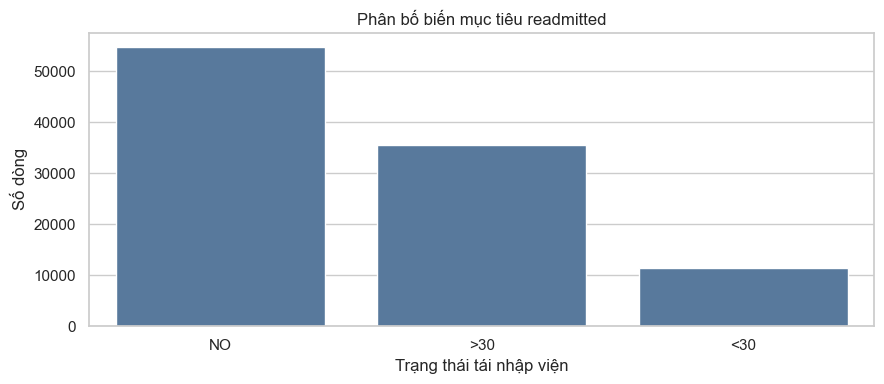

In [5]:
# Bar chart phân bố biến mục tiêu readmitted.
plot_bar_count(
    df,
    col="readmitted",
    order=readmitted_order,
    title="Phân bố biến mục tiêu readmitted",
    xlabel="Trạng thái tái nhập viện",
)

**Nhận xét:** cần chú ý tỷ lệ `NO`, `>30`, `<30`. Nhóm `<30` thường quan trọng nhất về mặt y tế vì thể hiện tái nhập viện sớm.

## 3. Tạo nhãn nhị phân

Tạo `readmitted_binary`: 
- `0 = NO`: không tái nhập viện.
- `1 = <30 hoặc >30`: có tái nhập viện.

In [6]:
binary_summary = frequency_table(df.assign(readmitted_binary_label=df["readmitted_binary"].map(binary_labels)), "readmitted_binary_label")
binary_summary

,readmitted_binary_label,count,percent
0,Không tái nhập viện,54861,53.91
1,Có tái nhập viện,46902,46.09


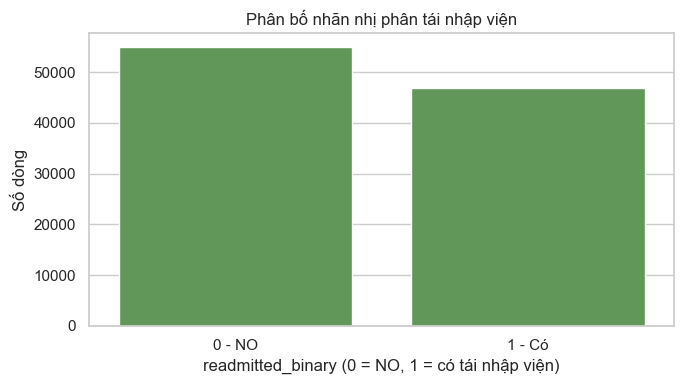

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="readmitted_binary", color="#59A14F")
plt.title("Phân bố nhãn nhị phân tái nhập viện")
plt.xlabel("readmitted_binary (0 = NO, 1 = có tái nhập viện)")
plt.ylabel("Số dòng")
plt.xticks([0, 1], ["0 - NO", "1 - Có"])
plt.tight_layout()
plt.show()

## 4. EDA tuổi

Phân tích phân bố nhóm tuổi và tỷ lệ tái nhập viện theo từng nhóm tuổi.

In [8]:
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)", "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]

frequency_table(df, "age")

,age,count,percent
0,[70-80),26066,25.61
1,[60-70),22482,22.09
2,[50-60),17256,16.96
3,[80-90),17197,16.90
4,[40-50),9685,9.52
5,[30-40),3775,3.71
6,[90-100),2793,2.74
7,[20-30),1657,1.63
8,[10-20),691,0.68
9,[0-10),161,0.16


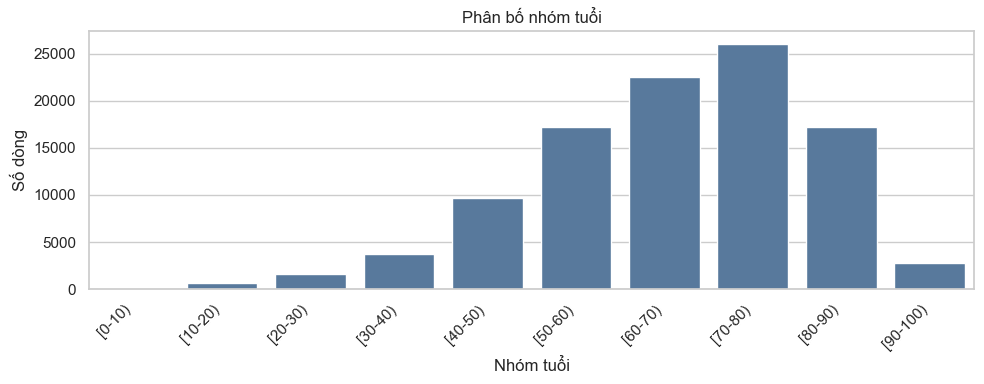

In [9]:
# Bar chart phân bố age.
plot_bar_count(
    df,
    col="age",
    order=age_order,
    title="Phân bố nhóm tuổi",
    xlabel="Nhóm tuổi",
    figsize=(10, 4),
    rotation=45,
)

In [10]:
# Bảng tỷ lệ tái nhập viện theo age.
readmission_rate_table(df, "age").loc[age_order]

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
age,,,
[0-10),161,18.01,2.55
[10-20),691,38.21,3.19
[20-30),1657,45.02,3.56
[30-40),3775,42.68,3.80
[40-50),9685,44.45,4.04
[50-60),17256,43.96,4.13
[60-70),22482,46.25,4.38
[70-80),26066,48.12,4.59
[80-90),17197,48.27,4.81


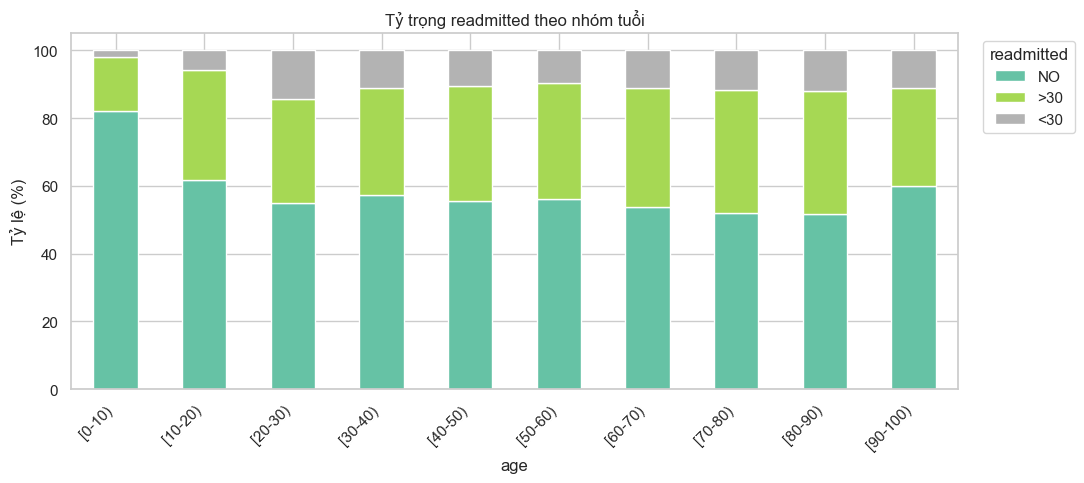

In [11]:
# Stacked bar: readmitted theo age.
plot_stacked_readmitted(df, "age", "Tỷ trọng readmitted theo nhóm tuổi", normalize=True, figsize=(11, 5))

**Nhận xét:** so sánh các nhóm tuổi lớn hơn, đặc biệt từ `[60-70)` trở lên, để xem tỷ lệ tái nhập viện có tăng theo tuổi hay không.

## 5. EDA giới tính

Kiểm tra phân bố giới tính và tỷ lệ tái nhập viện theo giới tính.

In [12]:
gender_order = ["Female", "Male"]
frequency_table(df, "gender")

,gender,count,percent
0,Female,54708,53.76
1,Male,47055,46.24


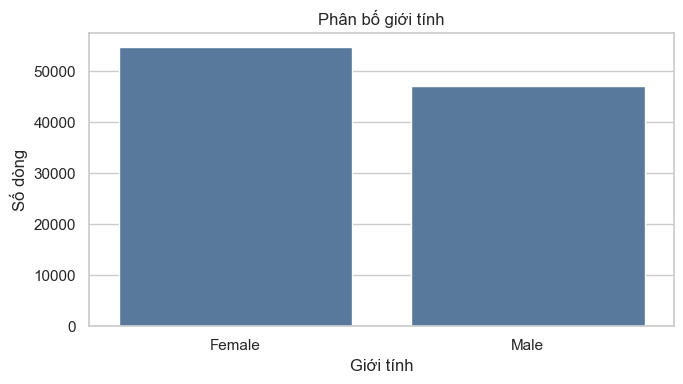

In [13]:
# Bar chart gender.
plot_bar_count(
    df,
    col="gender",
    order=gender_order,
    title="Phân bố giới tính",
    xlabel="Giới tính",
    figsize=(7, 4),
)

In [14]:
# Bảng tỷ lệ tái nhập viện theo gender.
readmission_rate_table(df, "gender")

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
gender,,,
Female,54708,46.92,4.48
Male,47055,45.12,4.30


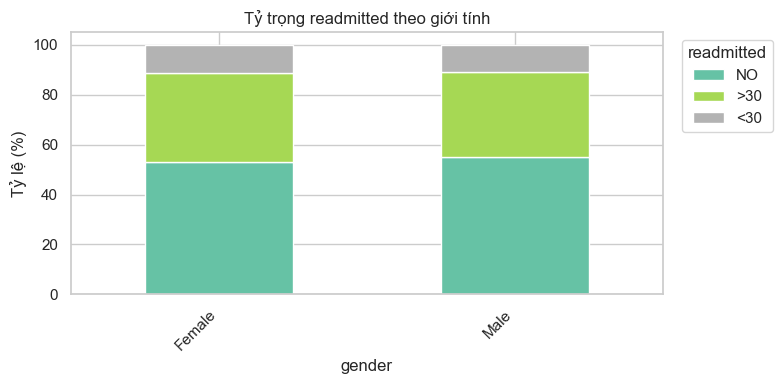

In [15]:
# Stacked bar: readmitted theo gender.
plot_stacked_readmitted(df, "gender", "Tỷ trọng readmitted theo giới tính", normalize=True, figsize=(8, 4))

**Nhận xét:** nếu tỷ lệ tái nhập viện giữa nam và nữ gần nhau, `gender` có thể không phải biến phân biệt mạnh khi đứng riêng lẻ.

## 6. EDA chủng tộc

Kiểm tra phân bố `race` và tỷ lệ tái nhập viện theo từng nhóm. Missing được giữ lại để thấy quy mô nhóm thiếu dữ liệu.

In [16]:
# Tạo bản sao hiển thị để đưa missing thành nhãn Unknown cho dễ đọc biểu đồ.
df_race = df.copy()
df_race["race_display"] = df_race["race"].fillna("Unknown")

race_order = df_race["race_display"].value_counts().index.tolist()
frequency_table(df_race, "race_display")

,race_display,count,percent
0,Caucasian,76099,74.78
1,AfricanAmerican,19210,18.88
2,Unknown,2271,2.23
3,Hispanic,2037,2.00
4,Other,1505,1.48
5,Asian,641,0.63


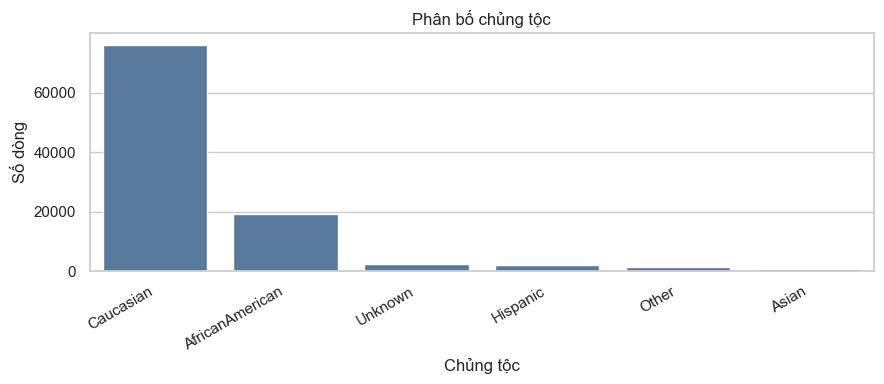

In [17]:
plot_bar_count(
    df_race,
    col="race_display",
    order=race_order,
    title="Phân bố chủng tộc",
    xlabel="Chủng tộc",
    figsize=(9, 4),
    rotation=30,
)

In [18]:
# Bảng tỷ lệ tái nhập viện theo race.
readmission_rate_table(df_race, "race_display")

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
race_display,,,
Caucasian,76099,46.93,4.39
AfricanAmerican,19210,45.75,4.51
Hispanic,2037,41.92,4.06
Other,1505,39.27,4.28
Asian,641,35.26,4.00
Unknown,2271,31.97,4.29


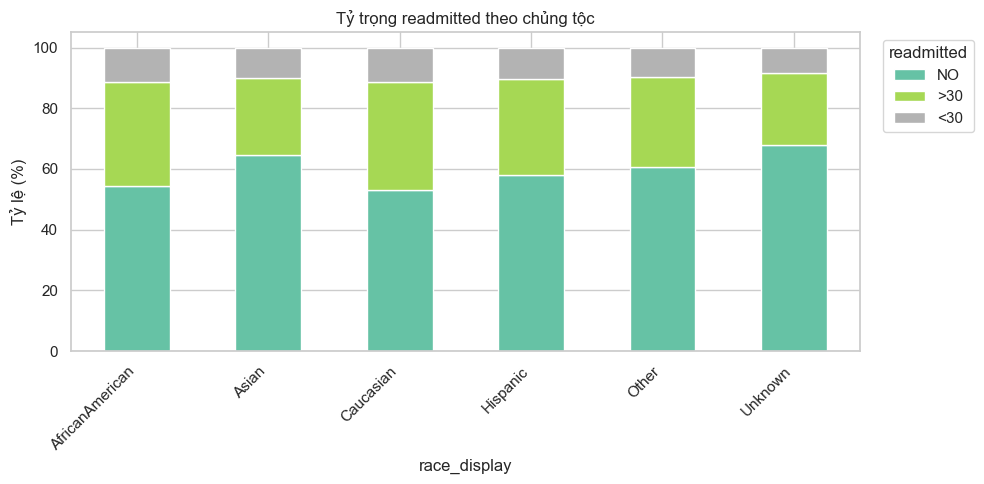

In [19]:
plot_stacked_readmitted(df_race, "race_display", "Tỷ trọng readmitted theo chủng tộc", normalize=True, figsize=(10, 5))

**Nhận xét:** cần đọc tỷ lệ cùng với số lượng mẫu. Nhóm có tỷ lệ cao nhưng số lượng quá ít thì kết luận có thể không ổn định.

## 7. EDA thời gian nằm viện

`time_in_hospital` là số ngày nằm viện trong lần ghi nhận. Đây là biến số quan trọng vì có thể phản ánh mức độ nặng hoặc độ phức tạp của ca điều trị.

In [20]:
df["time_in_hospital"].describe()

count   101763.00
mean         4.40
std          2.99
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         14.00
Name: time_in_hospital, dtype: float64

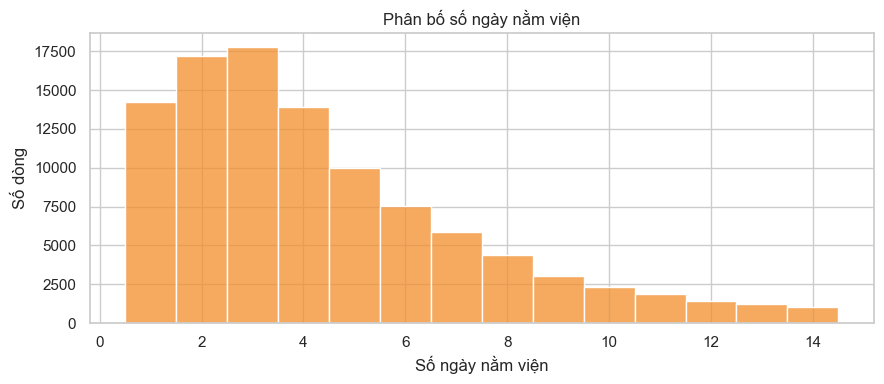

In [21]:
# Histogram time_in_hospital.
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="time_in_hospital", bins=14, color="#F28E2B", discrete=True)
plt.title("Phân bố số ngày nằm viện")
plt.xlabel("Số ngày nằm viện")
plt.ylabel("Số dòng")
plt.tight_layout()
plt.show()

## 8. So sánh thời gian nằm viện theo readmitted

So sánh phân phối và giá trị trung bình `time_in_hospital` giữa các nhóm `readmitted`.

In [22]:
time_by_readmitted = (
    df.groupby("readmitted")
    .agg(
        so_luong=("time_in_hospital", "size"),
        mean_time_in_hospital=("time_in_hospital", "mean"),
        median_time_in_hospital=("time_in_hospital", "median"),
        min_time_in_hospital=("time_in_hospital", "min"),
        max_time_in_hospital=("time_in_hospital", "max"),
    )
    .loc[readmitted_order]
)

time_by_readmitted

,so_luong,mean_time_in_hospital,median_time_in_hospital,min_time_in_hospital,max_time_in_hospital
readmitted,,,,,
NO,54861,4.25,3.00,1,14
>30,35545,4.50,4.00,1,14
<30,11357,4.77,4.00,1,14


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33304\2611429068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="readmitted", y="time_in_hospital", order=readmitted_order, palette="Set2")


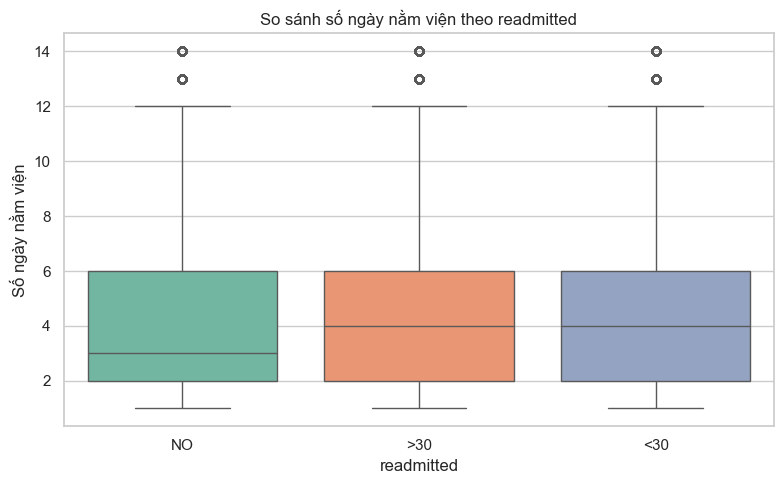

In [23]:
# Boxplot time_in_hospital theo readmitted.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="readmitted", y="time_in_hospital", order=readmitted_order, palette="Set2")
plt.title("So sánh số ngày nằm viện theo readmitted")
plt.xlabel("readmitted")
plt.ylabel("Số ngày nằm viện")
plt.tight_layout()
plt.show()

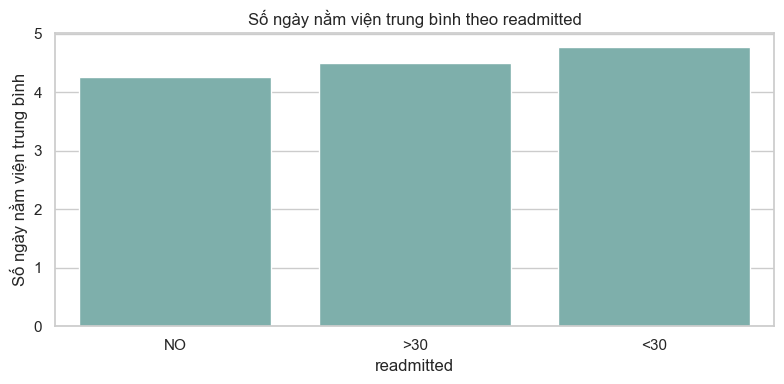

In [24]:
# Bar chart giá trị trung bình time_in_hospital theo readmitted.
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="readmitted", y="time_in_hospital", order=readmitted_order, estimator="mean", errorbar=None, color="#76B7B2")
plt.title("Số ngày nằm viện trung bình theo readmitted")
plt.xlabel("readmitted")
plt.ylabel("Số ngày nằm viện trung bình")
plt.tight_layout()
plt.show()

**Nhận xét:** nếu nhóm `<30` hoặc `>30` có thời gian nằm viện trung bình cao hơn `NO`, có thể xem `time_in_hospital` là biến liên quan đến nguy cơ tái nhập viện.

## 9. EDA loại nhập viện (`admission_type_id`)

Phân tích loại nhập viện, ví dụ cấp cứu, khẩn cấp, tự chọn, hoặc các nhóm chưa có thông tin.

In [25]:
frequency_table(df, "admission_type")

,admission_type,count,percent
0,1 - Emergency,53988,53.05
1,3 - Elective,18868,18.54
2,2 - Urgent,18480,18.16
3,6 - NULL,5291,5.20
4,5 - Not Available,4785,4.70
5,8 - Not Mapped,320,0.31
6,7 - Trauma Center,21,0.02
7,4 - Newborn,10,0.01


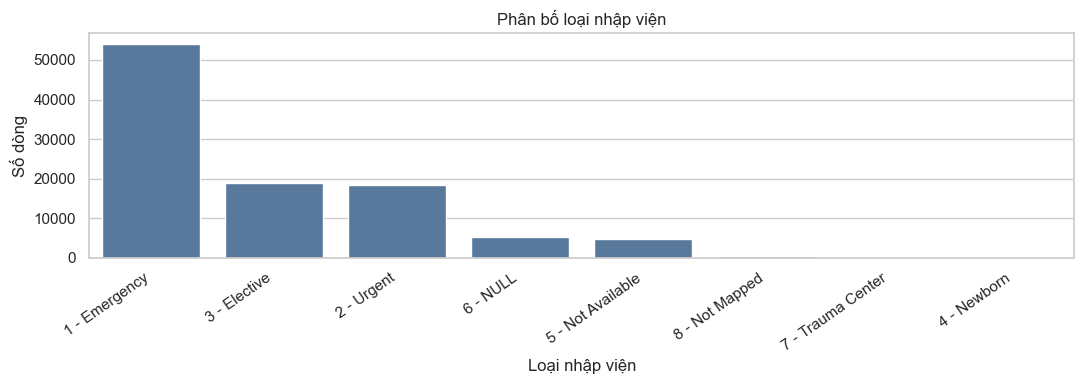

In [26]:
# Bar chart admission_type_id.
admission_type_order = df["admission_type"].value_counts().index
plot_bar_count(
    df,
    col="admission_type",
    order=admission_type_order,
    title="Phân bố loại nhập viện",
    xlabel="Loại nhập viện",
    figsize=(11, 4),
    rotation=35,
)

In [27]:
readmission_rate_table(df, "admission_type")

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
admission_type,,,
6 - NULL,5291,53.24,4.58
1 - Emergency,53988,47.29,4.38
5 - Not Available,4785,46.31,3.95
2 - Urgent,18480,46.09,4.61
3 - Elective,18868,40.85,4.32
8 - Not Mapped,320,34.69,3.06
4 - Newborn,10,30.00,3.20
7 - Trauma Center,21,0.00,4.86


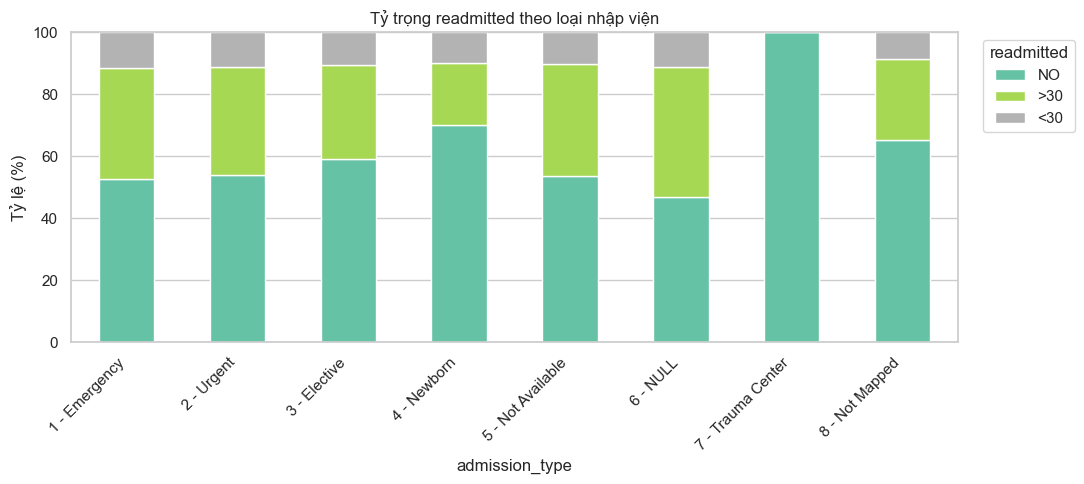

In [28]:
plot_stacked_readmitted(df, "admission_type", "Tỷ trọng readmitted theo loại nhập viện", normalize=True, figsize=(11, 5))

## 10. EDA nguồn nhập viện (`admission_source_id`)

Nguồn nhập viện cho biết bệnh nhân đến từ đâu: phòng cấp cứu, bác sĩ giới thiệu, chuyển từ bệnh viện khác,...

In [29]:
frequency_table(df, "admission_source")

,admission_source,count,percent
0,7 - Emergency Room,57492,56.50
1,1 - Physician Referral,29564,29.05
2,17 - NULL,6781,6.66
3,4 - Transfer from hospital,3187,3.13
4,6 - Transfer from health care facility,2264,2.22
5,2 - Clinic Referral,1104,1.08
6,5 - Transfer from SNF,855,0.84
7,3 - HMO Referral,187,0.18
8,20 - Not Mapped,161,0.16
9,9 - Not Available,125,0.12


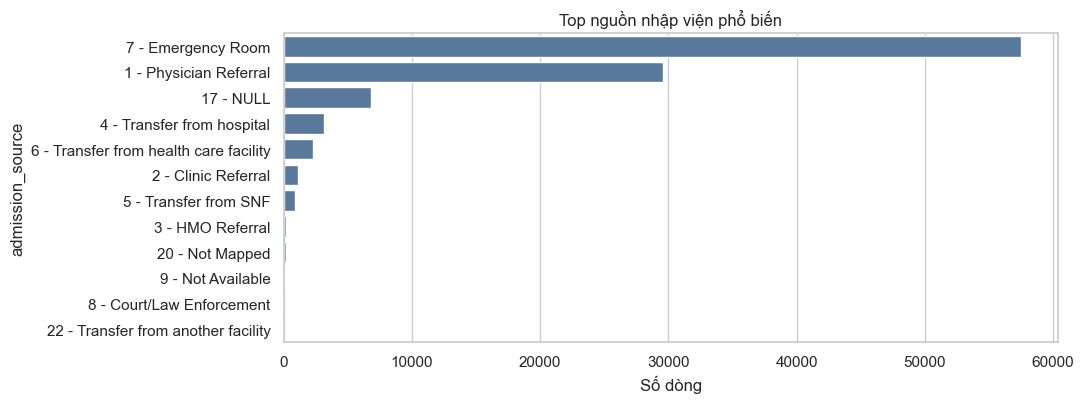

In [30]:
plot_top_categories(df, "admission_source", "Top nguồn nhập viện phổ biến", top_n=12)

In [31]:
readmission_rate_table(df, "admission_source")

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
admission_source,,,
20 - Not Mapped,161,63.98,4.58
7 - Emergency Room,57492,49.38,4.39
17 - NULL,6781,46.66,4.16
3 - HMO Referral,187,46.52,4.82
1 - Physician Referral,29564,43.19,4.26
22 - Transfer from another facility,12,41.67,10.00
5 - Transfer from SNF,855,39.42,5.83
2 - Clinic Referral,1104,38.13,4.68
8 - Court/Law Enforcement,16,37.50,5.56


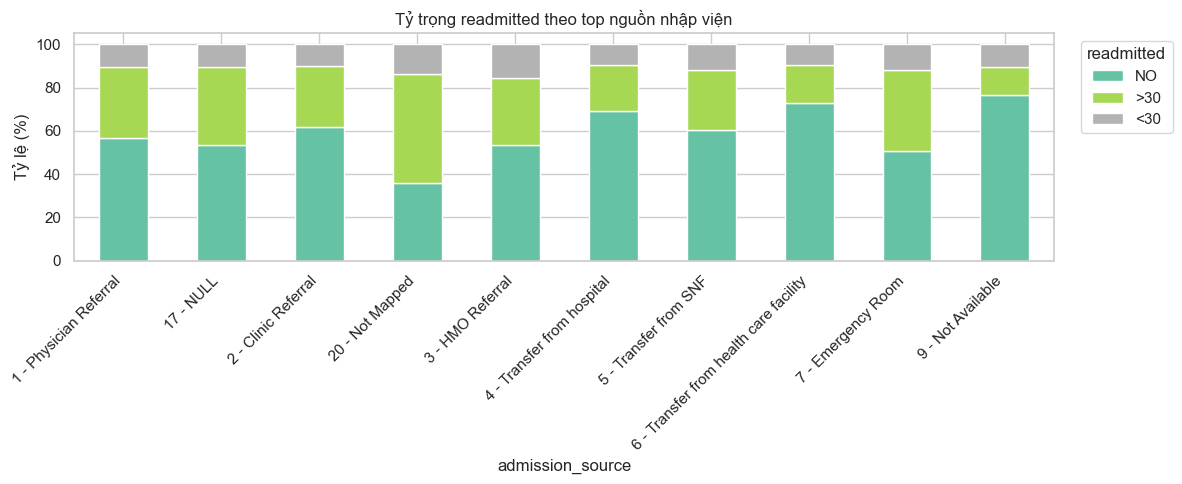

In [32]:
# Chỉ vẽ stacked bar cho top nguồn nhập viện để tránh biểu đồ quá dài.
top_sources = df["admission_source"].value_counts().head(10).index
plot_stacked_readmitted(
    df[df["admission_source"].isin(top_sources)],
    "admission_source",
    "Tỷ trọng readmitted theo top nguồn nhập viện",
    normalize=True,
    figsize=(12, 5),
)

## 11. EDA tình trạng xuất viện (`discharge_disposition_id`)

Tình trạng xuất viện có thể phản ánh mức độ hồi phục hoặc nơi bệnh nhân được chuyển đến sau điều trị.

In [33]:
frequency_table(df, "discharge_disposition")

,discharge_disposition,count,percent
0,1 - Discharged to home,60232,59.19
1,3 - Transferred to SNF,13954,13.71
2,6 - Home with home health service,12902,12.68
3,18 - NULL,3691,3.63
4,2 - Transferred to short term hospital,2128,2.09
5,22 - Transferred to rehab facility,1992,1.96
6,11 - Expired,1642,1.61
7,5 - Transferred to inpatient care,1184,1.16
8,25 - Not Mapped,989,0.97
9,4 - Transferred to ICF,815,0.80


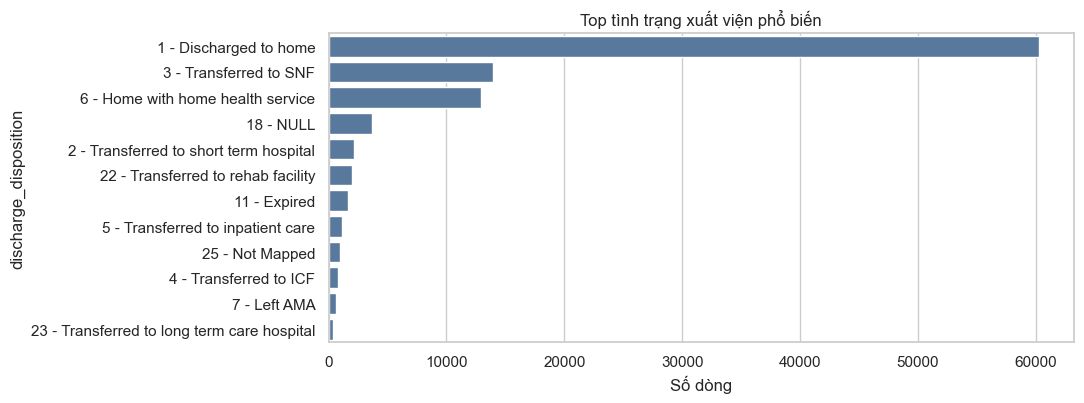

In [34]:
plot_top_categories(df, "discharge_disposition", "Top tình trạng xuất viện phổ biến", top_n=12)

In [35]:
readmission_rate_table(df, "discharge_disposition")

,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
discharge_disposition,,,
15 - Transferred within institution,63,73.02,6.40
10 - Neonate discharged to another hospital,6,66.67,6.17
12 - Still patient/expected return outpatient,3,66.67,3.67
28 - Transferred to psychiatric hospital,139,61.15,3.83
16 - Transferred to another institution outpatient,11,54.55,4.00
6 - Home with home health service,12902,54.26,5.44
22 - Transferred to rehab facility,1992,53.77,5.79
9 - Admitted as inpatient,21,52.38,4.62
5 - Transferred to inpatient care,1184,50.42,5.65


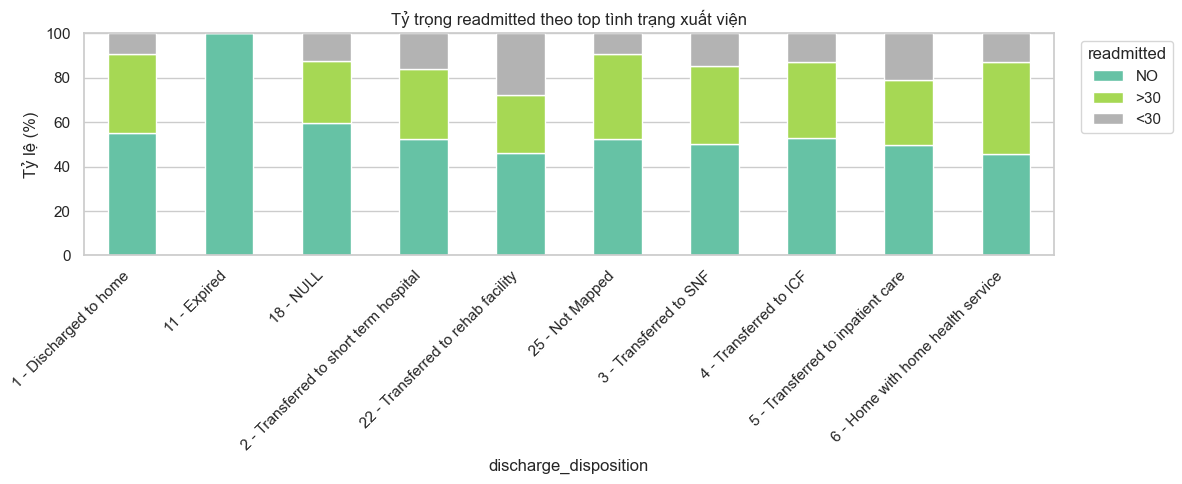

In [36]:
# Chỉ vẽ stacked bar cho top tình trạng xuất viện để biểu đồ dễ đọc.
top_discharge = df["discharge_disposition"].value_counts().head(10).index
plot_stacked_readmitted(
    df[df["discharge_disposition"].isin(top_discharge)],
    "discharge_disposition",
    "Tỷ trọng readmitted theo top tình trạng xuất viện",
    normalize=True,
    figsize=(12, 5),
)

## 12. Kết luận file 2

Tổng hợp các nhóm có xu hướng tái nhập viện dựa trên các bảng tỷ lệ và biểu đồ ở trên.

In [37]:
# Tổng hợp các nhóm có tỷ lệ tái nhập viện cao, đồng thời yêu cầu số lượng mẫu tối thiểu để tránh kết luận từ nhóm quá nhỏ.
min_group_size = 100

summary_tables = {
    "age": readmission_rate_table(df, "age"),
    "gender": readmission_rate_table(df, "gender"),
    "race": readmission_rate_table(df_race, "race_display"),
    "admission_type": readmission_rate_table(df, "admission_type"),
    "admission_source": readmission_rate_table(df, "admission_source"),
    "discharge_disposition": readmission_rate_table(df, "discharge_disposition"),
}

top_risk_groups = []
for feature_name, table in summary_tables.items():
    filtered = table[table["so_luong"] >= min_group_size].head(5).reset_index()
    group_col = filtered.columns[0]
    filtered = filtered.rename(columns={group_col: "nhom"})
    filtered.insert(0, "bien", feature_name)
    top_risk_groups.append(filtered)

top_risk_groups = pd.concat(top_risk_groups, ignore_index=True)
top_risk_groups

,bien,nhom,so_luong,ty_le_tai_nhap_vien,thoi_gian_nam_vien_tb
0,age,[80-90),17197,48.27,4.81
1,age,[70-80),26066,48.12,4.59
2,age,[60-70),22482,46.25,4.38
3,age,[20-30),1657,45.02,3.56
4,age,[40-50),9685,44.45,4.04
5,gender,Female,54708,46.92,4.48
6,gender,Male,47055,45.12,4.30
7,race,Caucasian,76099,46.93,4.39
8,race,AfricanAmerican,19210,45.75,4.51
9,race,Hispanic,2037,41.92,4.06


### Nhận xét đề xuất

- **Biến mục tiêu:** `readmitted` có 3 lớp (`NO`, `>30`, `<30`). Có thể dùng bản 3 lớp cho phân tích chi tiết hoặc dùng `readmitted_binary` cho bài toán dự đoán có/không tái nhập viện.
- **Tuổi:** cần chú ý các nhóm tuổi cao. Nếu stacked bar cho thấy tỷ lệ `>30` hoặc `<30` tăng ở nhóm lớn tuổi, tuổi là biến nên giữ.
- **Giới tính:** so sánh nam/nữ bằng tỷ lệ tái nhập viện, không chỉ bằng số lượng tuyệt đối. Nếu hai tỷ lệ gần nhau thì ảnh hưởng đơn biến có thể yếu.
- **Chủng tộc:** cần xử lý missing (`Unknown`) và tránh kết luận mạnh với nhóm có số lượng mẫu nhỏ.
- **Thời gian nằm viện:** nếu nhóm tái nhập viện có `time_in_hospital` trung bình/median cao hơn nhóm `NO`, đây là biến có liên quan đáng chú ý.
- **Loại/nguồn nhập viện:** các nhóm cấp cứu, chuyển viện hoặc không rõ thông tin có thể có xu hướng tái nhập viện khác nhau; nên giữ để thử trong mô hình.
- **Tình trạng xuất viện:** các nhóm chuyển sang cơ sở chăm sóc khác hoặc chăm sóc tại nhà có thể phản ánh bệnh nhân nặng hơn, nên kiểm tra kỹ tỷ lệ tái nhập viện.

Kết luận cuối cùng nên dựa vào bảng `top_risk_groups` sau khi chạy notebook, vì bảng này tự tính nhóm có tỷ lệ tái nhập viện cao và có đủ số lượng mẫu.